# 09 — Payment status funnel with share of total

Count and gross amount per `payment_status` (`pending`, `completed`, `failed`, `refunded`), with each status's share of all payments via a CTE plus a window `SUM() OVER()`. Mirrors `docs/Client_Querires.md` §2.2.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH status_counts AS (
  SELECT payment_status, COUNT(*) AS n, SUM(amount) AS gross_amount
  FROM client_payments
  GROUP BY payment_status
)
SELECT
  payment_status,
  n,
  gross_amount,
  ROUND(100 * n / SUM(n) OVER (), 1) AS pct_of_all_payments
FROM status_counts
ORDER BY n DESC;
"""

df = pd.read_sql(text(query), engine)
print(df)

  payment_status   n  gross_amount  pct_of_all_payments
0      completed  30         138.0                100.0


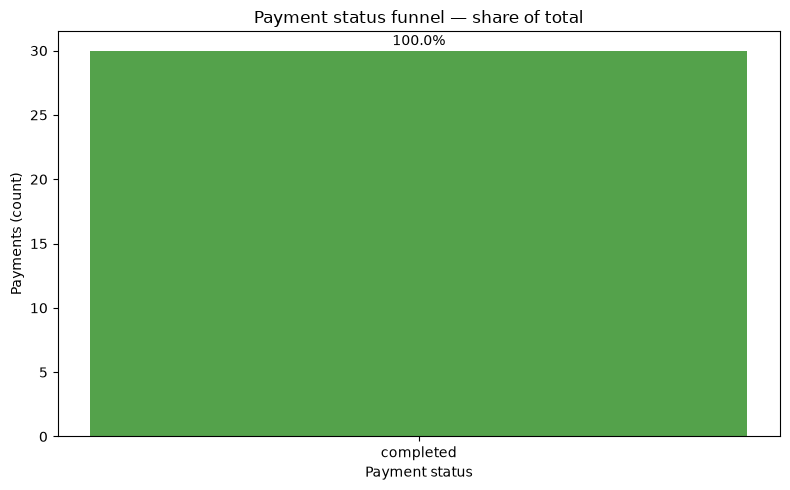

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

colors = {
    "completed": "#54A24B",
    "pending": "#F58518",
    "failed": "#E45756",
    "refunded": "#4C78A8",
}
bar_colors = [colors.get(s, "#B0B0B0") for s in df["payment_status"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df["payment_status"], df["n"], color=bar_colors)
ax.set_xlabel("Payment status")
ax.set_ylabel("Payments (count)")
ax.set_title("Payment status funnel — share of total")

for bar, pct in zip(bars, df["pct_of_all_payments"]):
    ax.annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
    )

fig.tight_layout()

# os.makedirs("../assets/img", exist_ok=True)
# fig.savefig("../assets/img/payment_status_funnel.png", dpi=150)
plt.show()